## Data Source

In [ ]:
Data obtained from the NYC Taxi & Limousine Commission (TLC) Trip Record Data.
URL: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page
Year: 2025

In [ ]:
import pandas as pd
import numpy as np
import osg
import gc
print(" libraries loade succesfully")

ModuleNotFoundError: No module named 'osg'

In [ ]:
# Clean month by month and save
DATA_FOLDER = "data/converter"
OUTPUT_FOLDER = "data/processed"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

def clean_one_month(filepath):
    df = pd.read_csv(filepath, low_memory=False)
    
    # Drop heavy unused columns immediately
    cols_to_drop = ["store_and_fwd_flag", "improvement_surcharge",
                    "congestion_surcharge", "Airport_fee", "RatecodeID"]
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    
    # Parse datetimes
    df["tpep_pickup_datetime"]  = pd.to_datetime(df["tpep_pickup_datetime"])
    df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])
    
    # Compute duration
    df["duration_minutes"] = (
        df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
    ).dt.total_seconds() / 60
    
    # Filter
    df = df[
        df["duration_minutes"].between(1, 120) &
        (df["trip_distance"] > 0) &
        df["PULocationID"].notna() &
        df["DOLocationID"].notna()
    ].reset_index(drop=True)
    
    return df

# Process all 12 months one at a time
all_clean = []

for month in range(1, 13):
    filepath = os.path.join(DATA_FOLDER, f"yellow_tripdata_2025-{month:02d}.csv")
    print(f"Processing month {month:02d}...", end=" ")
    
    df_month = clean_one_month(filepath)
    print(f"{len(df_month):,} rows kept")
    
    all_clean.append(df_month)
    gc.collect()

# Combine all clean months
print("\nCombining all months...")
df_clean = pd.concat(all_clean, ignore_index=True)
print(f"\n succesful Total clean rows: {len(df_clean):,}")
print(f"succesful Total columns: {df_clean.shape[1]}")

Processing month 01... 3,368,764 rows kept
Processing month 02... 3,459,772 rows kept
Processing month 03... 4,002,800 rows kept
Processing month 04... 3,828,074 rows kept
Processing month 05... 4,367,724 rows kept
Processing month 06... 4,102,744 rows kept
Processing month 07... 3,703,679 rows kept
Processing month 08... 3,405,811 rows kept
Processing month 09... 4,050,507 rows kept
Processing month 10... 4,215,793 rows kept
Processing month 11... 3,992,161 rows kept
Processing month 12... 4,075,376 rows kept

Combining all months...

 succesful Total clean rows: 46,573,205
succesful Total columns: 16


In [ ]:
# Save the cleaned data
df_clean.to_csv("data/processed/yellow_taxi_2025_clean.csv", index=False)
print("✅ Saved to data/processed/yellow_taxi_2025_clean.csv")

✅ Saved to data/processed/yellow_taxi_2025_clean.csv


In [ ]:
df_clean.to_parquet("data/processed/yellow_taxi_2025_clean.parquet", index=False)
print("Success Parquet saved!")

Success Parquet saved!


## Phase 2: Exploratory Data Analysis
In this section we explore the cleaned dataset visually to understand patterns in NYC yellow taxi trips across 2025.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import gc
print("Successful visualization libraries")

Successful visualization libraries


In [ ]:
# Load only 2 million rows - enough for perfect analysis
df = pd.read_csv(
    "data/processed/yellow_taxi_2025_clean.csv",
    nrows=2000000
)

print(f"✅ Loaded {len(df):,} rows")
print(f"✅ Columns: {df.shape[1]}")
print(f"✅ Ready for analysis!")

✅ Loaded 2,000,000 rows
✅ Columns: 16
✅ Ready for analysis!


In [ ]:
print(f"Rows loaded: {len(df):,}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**3:.2f} GB")

Rows loaded: 2,000,000
Memory usage: 0.31 GB


### Chart 1: Distribution of Trip This showes where most NYC taxi trips fall in term of duration.

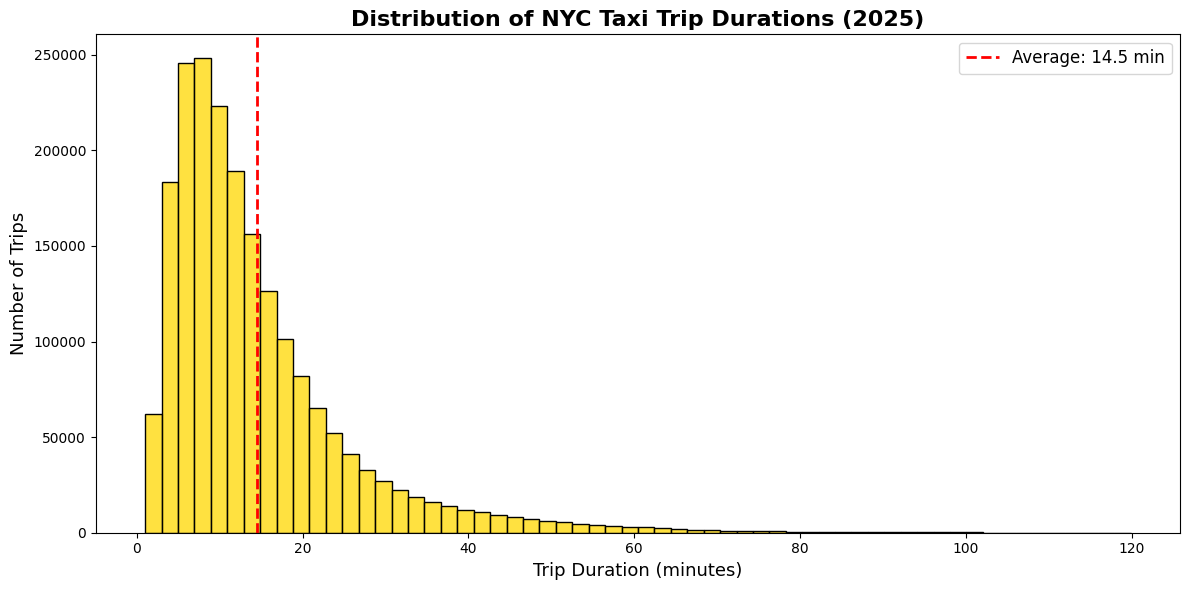

✅ Average trip duration: 14.5 minutes


In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(df["duration_minutes"], bins=60, color="#FFD700", edgecolor="black")

plt.title("Distribution of NYC Taxi Trip Durations (2025)", fontsize=16, fontweight="bold")
plt.xlabel("Trip Duration (minutes)", fontsize=13)
plt.ylabel("Number of Trips", fontsize=13)

# Add a vertical line at the average
avg = df["duration_minutes"].mean()
plt.axvline(avg, color="red", linestyle="--", linewidth=2, label=f"Average: {avg:.1f} min")
plt.legend(fontsize=12)

plt.tight_layout()
plt.savefig("chart1_duration_distribution.png", dpi=150)
plt.show()
print(f"✅ Average trip duration: {avg:.1f} minutes")

### Chart 2: Average Trip Duration by Hour of Day This reveals how traffic congestion affects trip times throughout the day.

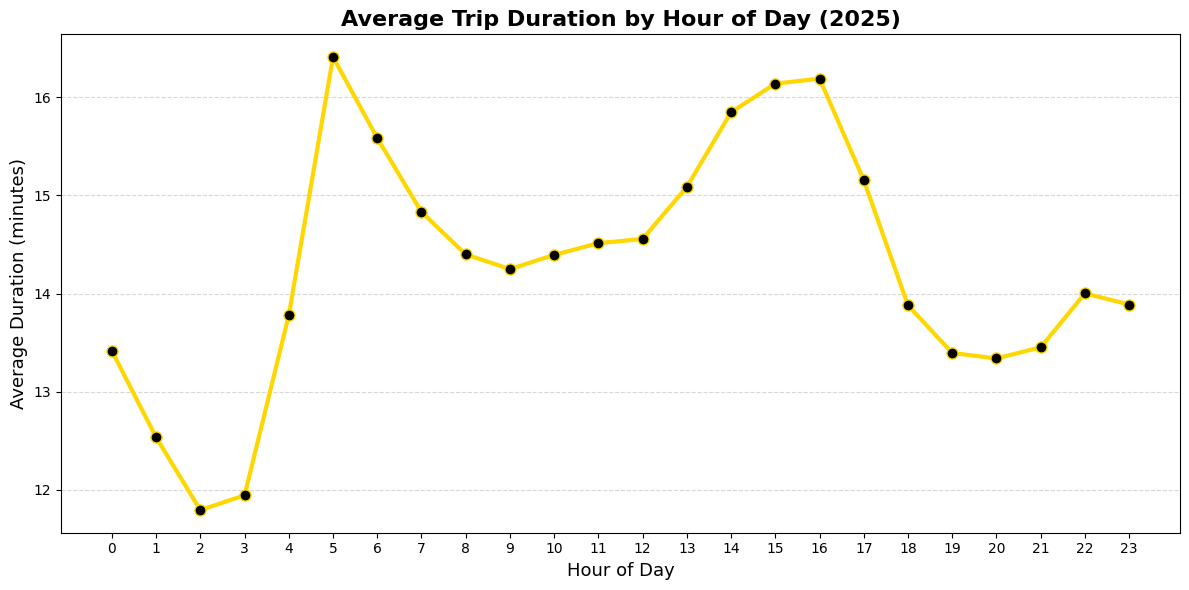

In [ ]:
# Extract hour from pickup time
df["pickup_hour"] = pd.to_datetime(df["tpep_pickup_datetime"]).dt.hour

hourly = df.groupby("pickup_hour")["duration_minutes"].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(hourly["pickup_hour"], hourly["duration_minutes"], 
         color="#FFD700", linewidth=3, marker="o", markersize=8, markerfacecolor="black")

plt.title("Average Trip Duration by Hour of Day (2025)", fontsize=16, fontweight="bold")
plt.xlabel("Hour of Day", fontsize=13)
plt.ylabel("Average Duration (minutes)", fontsize=13)
plt.xticks(range(0, 24))
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("chart2_duration_by_hour.png", dpi=150)
plt.show()

### Chart 3: Average Trip Duration by Day of Week This shows how travel patterns differ between weekdays and weekends.

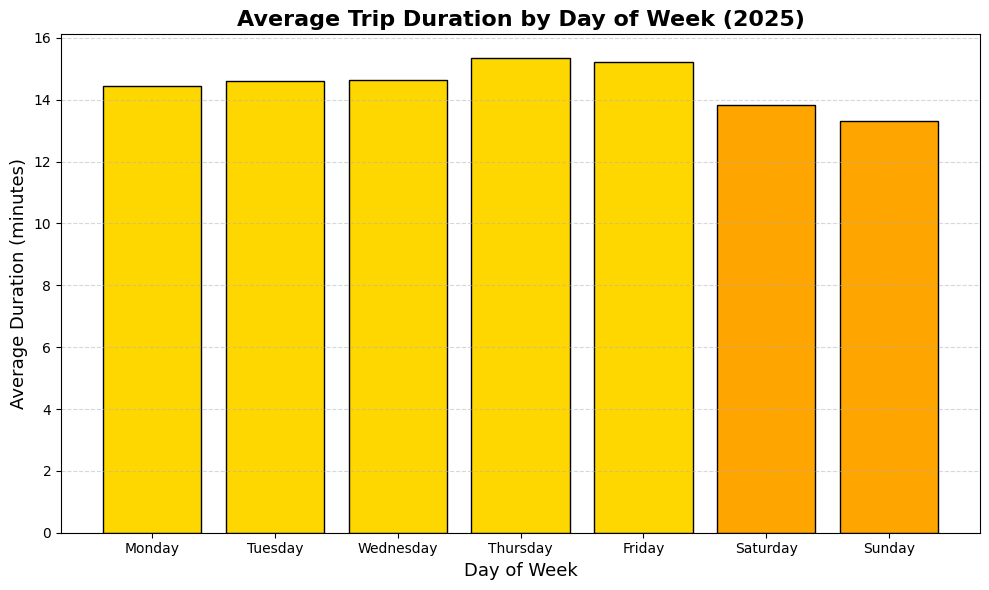

In [ ]:
df["day_of_week"] = pd.to_datetime(df["tpep_pickup_datetime"]).dt.dayofweek
day_names = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

daily = df.groupby("day_of_week")["duration_minutes"].mean().reset_index()

plt.figure(figsize=(10, 6))
bars = plt.bar(day_names, daily["duration_minutes"], 
               color=["#FFD700"]*5 + ["#FFA500"]*2, edgecolor="black")

plt.title("Average Trip Duration by Day of Week (2025)", fontsize=16, fontweight="bold")
plt.xlabel("Day of Week", fontsize=13)
plt.ylabel("Average Duration (minutes)", fontsize=13)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("chart3_duration_by_day.png", dpi=150)
plt.show()

### Chart 4: Top 10 Busiest Pickup Zones This identifies the most active taxi pickup locations in NYC.

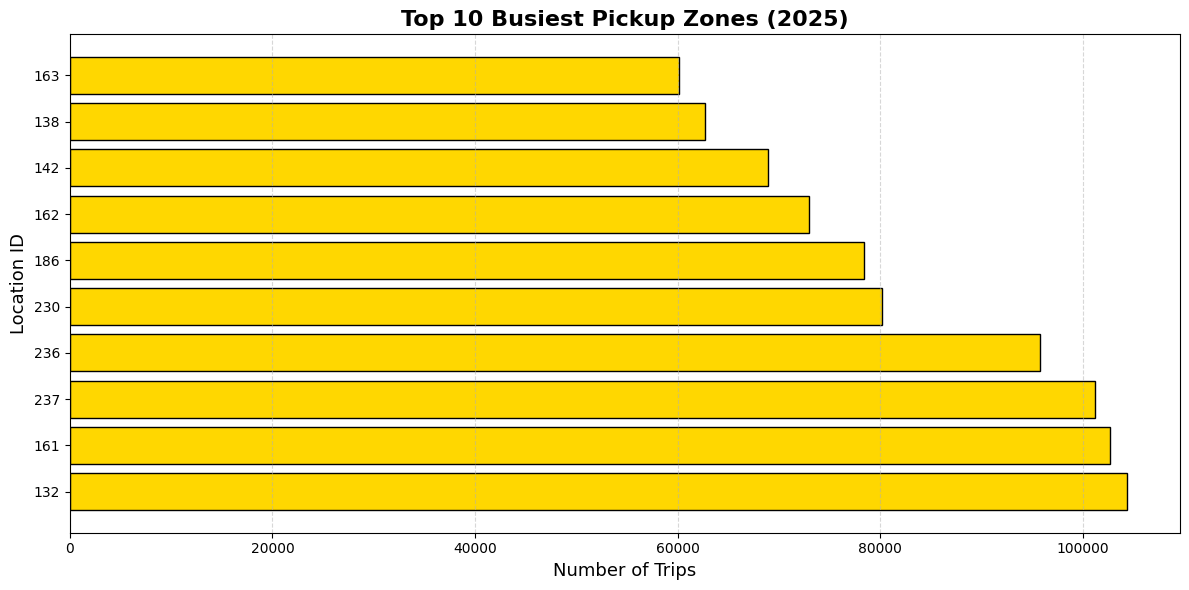

In [ ]:
top_zones = df["PULocationID"].value_counts().head(10).reset_index()
top_zones.columns = ["LocationID", "trip_count"]

plt.figure(figsize=(12, 6))
bars = plt.barh(top_zones["LocationID"].astype(str), 
                top_zones["trip_count"],
                color="#FFD700", edgecolor="black")

plt.title("Top 10 Busiest Pickup Zones (2025)", fontsize=16, fontweight="bold")
plt.xlabel("Number of Trips", fontsize=13)
plt.ylabel("Location ID", fontsize=13)
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("chart4_top_pickup_zones.png", dpi=150)
plt.show()

### Chart 5: Heatmap of Trip Count by Hour and Day of Week This reveals when NYC taxis are busiest throughout the week.

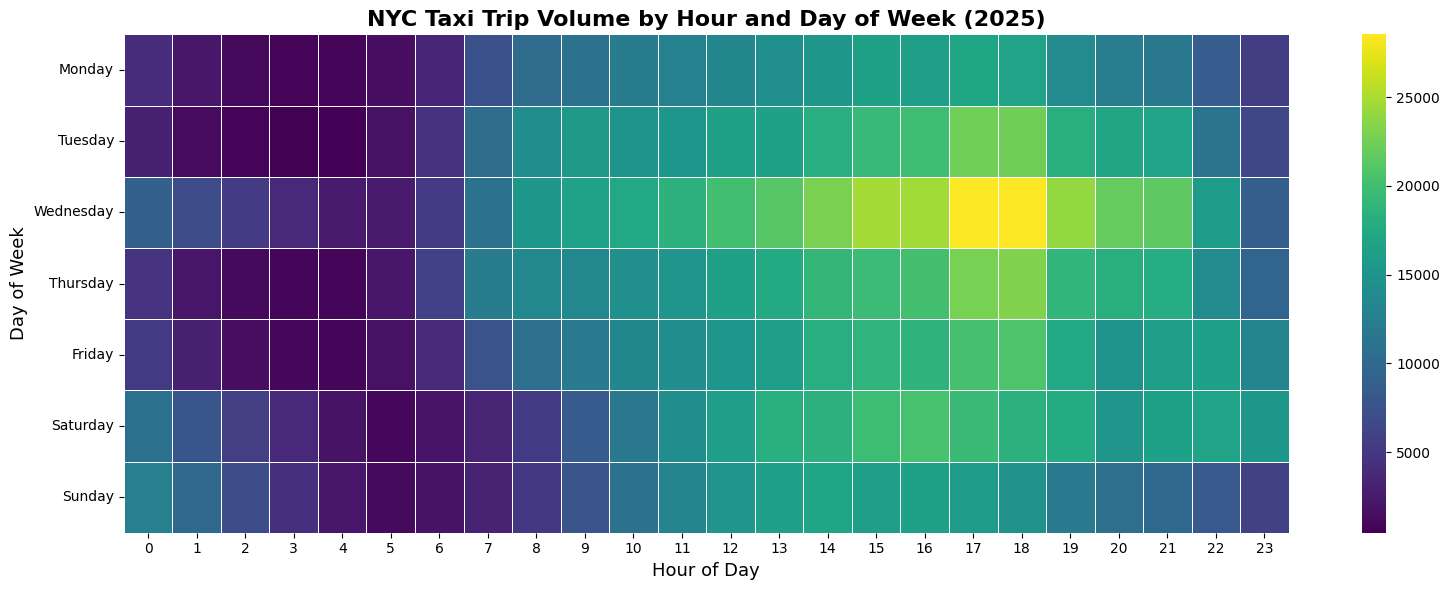

In [ ]:
df["pickup_hour"] = pd.to_datetime(df["tpep_pickup_datetime"]).dt.hour
df["day_of_week"] = pd.to_datetime(df["tpep_pickup_datetime"]).dt.dayofweek
day_names = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

heatmap_data = df.groupby(["day_of_week", "pickup_hour"]).size().unstack()
heatmap_data.index = day_names

plt.figure(figsize=(16, 6))
sns.heatmap(heatmap_data, 
            cmap="viridis",
            linewidths=0.5,
            fmt=",",
            annot=False)

plt.title("NYC Taxi Trip Volume by Hour and Day of Week (2025)", 
          fontsize=16, fontweight="bold")
plt.xlabel("Hour of Day", fontsize=13)
plt.ylabel("Day of Week", fontsize=13)

plt.tight_layout()
plt.savefig("chart5_heatmap.png", dpi=150)
plt.show()

### Chart 6: Trip Volume by Month This shows how taxi demand changes across different months of 2025.

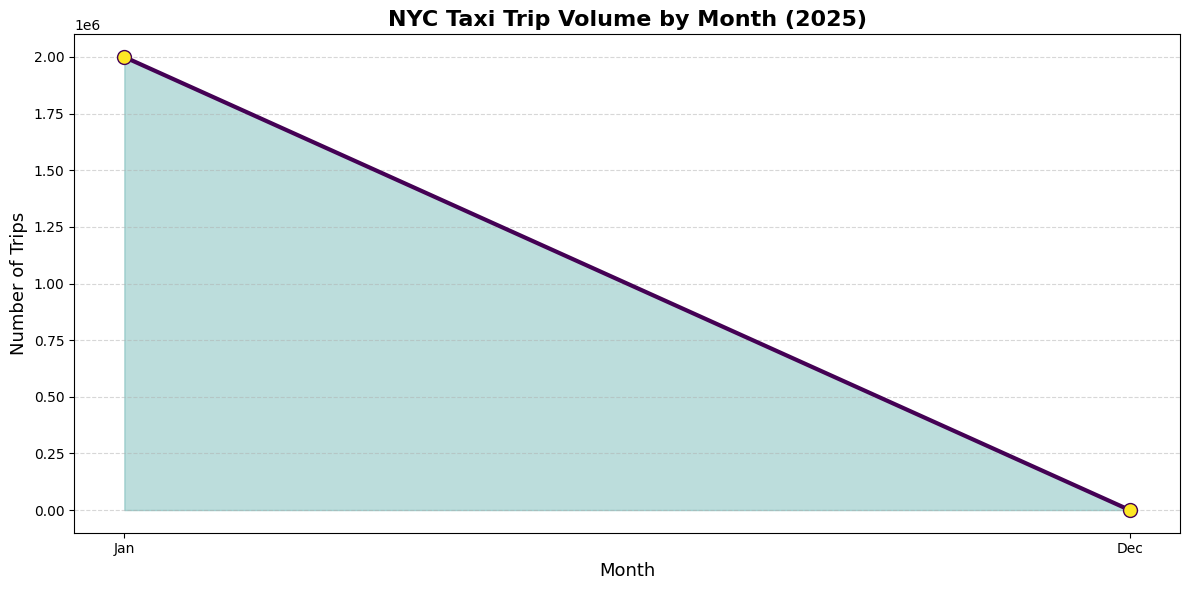

In [ ]:
df["month"] = pd.to_datetime(df["tpep_pickup_datetime"]).dt.month

monthly = df.groupby("month").size().reset_index()
monthly.columns = ["month", "trip_count"]

# Use actual month numbers from data, not hardcoded 12 months
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]
monthly["month_name"] = monthly["month"].apply(lambda x: month_labels[x-1])

plt.figure(figsize=(12, 6))
plt.plot(monthly["month_name"], monthly["trip_count"], 
         color="#440154", linewidth=3, 
         marker="o", markersize=10, 
         markerfacecolor="#FDE725")

plt.fill_between(monthly["month_name"], monthly["trip_count"], 
                 alpha=0.3, color="#21908C")

plt.title("NYC Taxi Trip Volume by Month (2025)", fontsize=16, fontweight="bold")
plt.xlabel("Month", fontsize=13)
plt.ylabel("Number of Trips", fontsize=13)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("chart6_monthly_volume.png", dpi=150)
plt.show()

### Chart 7: Average Trip Duration by Passenger Count This explores whether group size affects taxi trip duration.

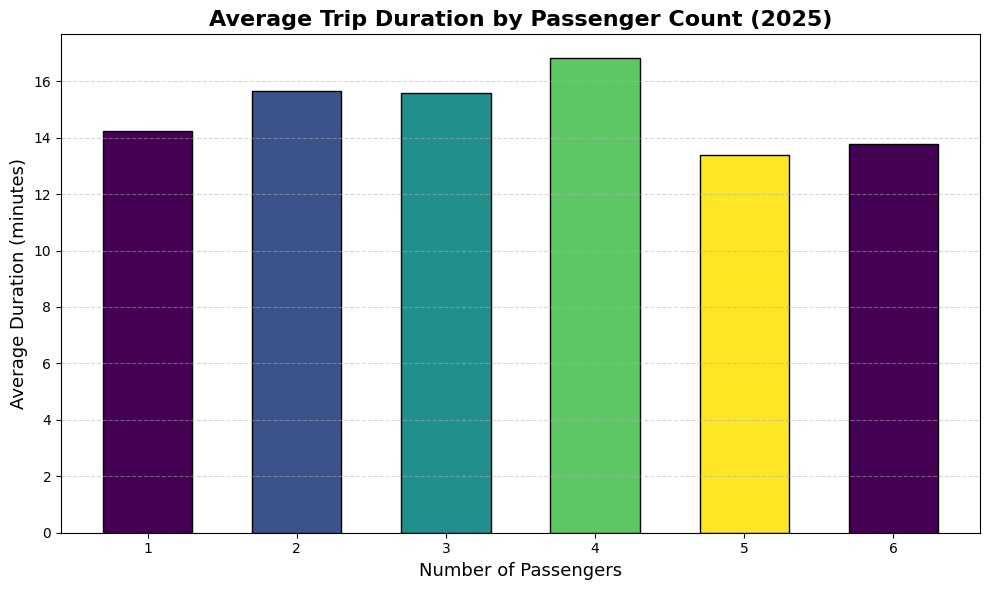

In [ ]:
passenger = df[df["passenger_count"].between(1, 6)]\
    .groupby("passenger_count")["duration_minutes"].mean().reset_index()

plt.figure(figsize=(10, 6))
bars = plt.bar(passenger["passenger_count"], 
               passenger["duration_minutes"],
               color=["#440154","#3B528B","#21908C",
                      "#5DC863","#FDE725","#440154"],
               edgecolor="black", width=0.6)

plt.title("Average Trip Duration by Passenger Count (2025)", 
          fontsize=16, fontweight="bold")
plt.xlabel("Number of Passengers", fontsize=13)
plt.ylabel("Average Duration (minutes)", fontsize=13)
plt.xticks([1,2,3,4,5,6])
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("chart7_duration_by_passengers.png", dpi=150)
plt.show()

### Chart 8: Top 10 Busiest Pickup Zones by Neighborhood This identifies the most active taxi pickup neighborhoods in NYC.

In [ ]:
import urllib.request

# Download official NYC taxi zone lookup table
url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi+_zone_lookup.csv"
urllib.request.urlretrieve(url, "data/taxi_zone_lookup.csv")
print("Successful Zone lookup downloaded!")

Successful Zone lookup downloaded!


In [ ]:
# Load zone lookup table
zones = pd.read_csv("data/taxi_zone_lookup.csv")
print(zones.head())
print(zones.columns.tolist())

   LocationID        Borough                     Zone service_zone
0           1            EWR           Newark Airport          EWR
1           2         Queens              Jamaica Bay    Boro Zone
2           3          Bronx  Allerton/Pelham Gardens    Boro Zone
3           4      Manhattan            Alphabet City  Yellow Zone
4           5  Staten Island            Arden Heights    Boro Zone
['LocationID', 'Borough', 'Zone', 'service_zone']


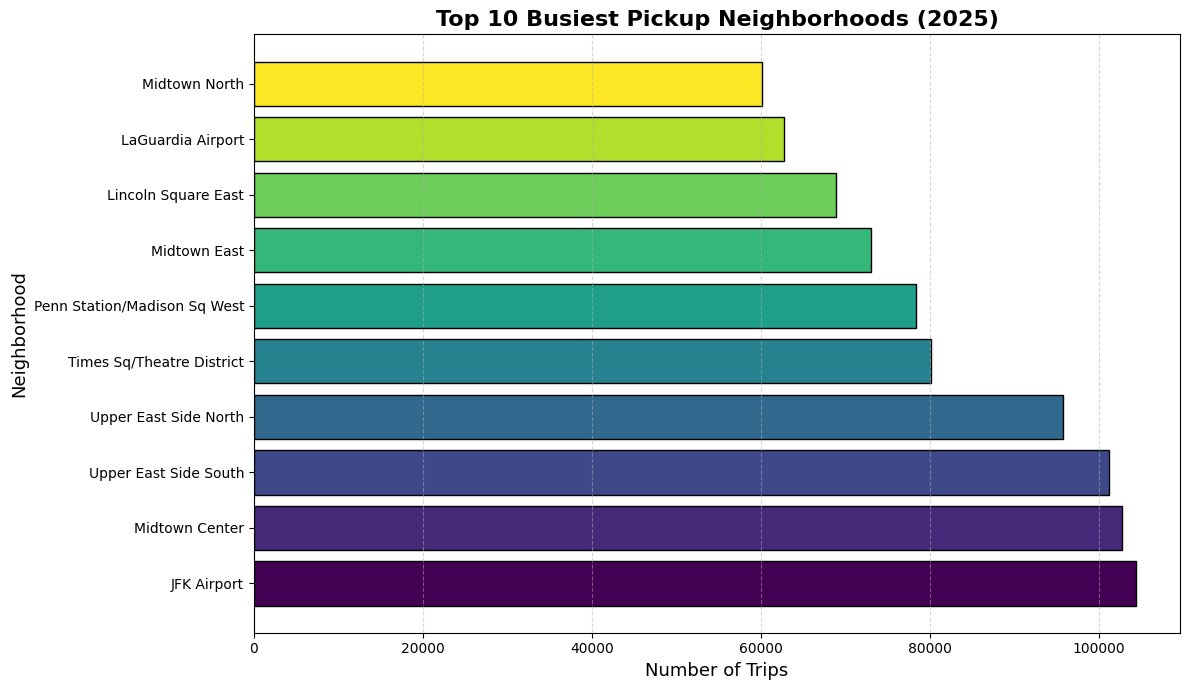

In [ ]:
top_zones = df["PULocationID"].value_counts().head(10).reset_index()
top_zones.columns = ["LocationID", "trip_count"]

top_zones = top_zones.merge(zones[["LocationID", "Zone", "Borough"]], 
                            on="LocationID", how="left")

plt.figure(figsize=(12, 7))
bars = plt.barh(top_zones["Zone"], 
                top_zones["trip_count"],
                color=["#440154","#482878","#3E4989","#31688E","#26828E",
                       "#1F9E89","#35B779","#6DCD59","#B4DE2C","#FDE725"],
                edgecolor="black")

plt.title("Top 10 Busiest Pickup Neighborhoods (2025)", 
          fontsize=16, fontweight="bold")
plt.xlabel("Number of Trips", fontsize=13)
plt.ylabel("Neighborhood", fontsize=13)
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("chart8_top_pickup_zones.png", dpi=150)
plt.show()

## Phase 3: Feature Engineering
Creating a feature to help my model better predict trip duration.
These features capture time patterns, location behavior, and historical averages.

In [ ]:
# Convert pickup datetime once
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])

# Time based features
df["pickup_hour"]  = df["tpep_pickup_datetime"].dt.hour
df["day_of_week"]  = df["tpep_pickup_datetime"].dt.dayofweek
df["month"]        = df["tpep_pickup_datetime"].dt.month
df["is_weekend"]   = (df["day_of_week"] >= 5).astype(int)
df["is_rush_hour"] = (
    df["pickup_hour"].between(7, 9) | 
    df["pickup_hour"].between(17, 19)
).astype(int)

print("Time features created Successfully!")
print(f"Rush hour trips: {df['is_rush_hour'].sum():,}")
print(f"Weekend trips: {df['is_weekend'].sum():,}")

Time features created Successfully!
Rush hour trips: 626,303
Weekend trips: 524,846


In [ ]:
# Route average duration - most powerful feature!
route_avg = df.groupby(["PULocationID", "DOLocationID"])["duration_minutes"]\
              .mean().reset_index()
route_avg.columns = ["PULocationID", "DOLocationID", "route_avg_duration"]

# Merge back onto main dataframe
df = df.merge(route_avg, on=["PULocationID", "DOLocationID"], how="left")

print("Route average duration created Successfully!")
print(f"Unique routes: {route_avg.shape[0]:,}")
print(f"Sample route averages:")
print(route_avg.head())

Route average duration created Successfully!
Unique routes: 22,063
Sample route averages:
   PULocationID  DOLocationID  route_avg_duration
0             1             1            4.266667
1             1             6           25.066667
2             1            33           40.983333
3             1            68           30.266667
4             1            89           37.300000


In [ ]:
# Congestion fee flag
df["congestion_fee_flag"] = (df["cbd_congestion_fee"] > 0).astype(int)

# Borough features from zone lookup
df = df.merge(zones[["LocationID","Borough"]].rename(
              columns={"LocationID":"PULocationID","Borough":"pickup_borough"}),
              on="PULocationID", how="left")

df = df.merge(zones[["LocationID","Borough"]].rename(
              columns={"LocationID":"DOLocationID","Borough":"dropoff_borough"}),
              on="DOLocationID", how="left")

print("All features created Successfully!")
print(f"Total columns now: {df.shape[1]}")
print(f"\nNew columns added:")
print(["pickup_hour","day_of_week","month","is_weekend",
       "is_rush_hour","route_avg_duration",
       "congestion_fee_flag","pickup_borough","dropoff_borough"])

All features created Successfully!
Total columns now: 25

New columns added:
['pickup_hour', 'day_of_week', 'month', 'is_weekend', 'is_rush_hour', 'route_avg_duration', 'congestion_fee_flag', 'pickup_borough', 'dropoff_borough']


## Phase 4: Modeling
Building and comparing multiple models to predict NYC taxi trip duration.
We start simple and work up to our most powerful model - LightGBM.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Features we'll use for modeling
features = [
    "trip_distance", "pickup_hour", "day_of_week", 
    "month", "is_weekend", "is_rush_hour",
    "route_avg_duration", "congestion_fee_flag",
    "PULocationID", "DOLocationID"
]

target = "duration_minutes"

# Drop any rows with missing values in our features
df_model = df[features + [target]].dropna()

# Split by time - first 80% train, last 20% test
split = int(len(df_model) * 0.8)
train = df_model.iloc[:split]
test  = df_model.iloc[split:]

X_train = train[features]
y_train = train[target]
X_test  = test[features]
y_test  = test[target]

print(f"Success in Training rows: {len(X_train):,}")
print(f"Success in Testing rows: {len(X_test):,}")

Success in Training rows: 1,600,000
Success in Testing rows: 400,000


In [ ]:
# Recreate all features quickly
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])

# Time features
df["pickup_hour"]  = df["tpep_pickup_datetime"].dt.hour
df["day_of_week"]  = df["tpep_pickup_datetime"].dt.dayofweek
df["month"]        = df["tpep_pickup_datetime"].dt.month
df["is_weekend"]   = (df["day_of_week"] >= 5).astype(int)
df["is_rush_hour"] = (
    df["pickup_hour"].between(7, 9) | 
    df["pickup_hour"].between(17, 19)
).astype(int)

# Route average duration
route_avg = df.groupby(["PULocationID", "DOLocationID"])["duration_minutes"]\
              .mean().reset_index()
route_avg.columns = ["PULocationID", "DOLocationID", "route_avg_duration"]
df = df.merge(route_avg, on=["PULocationID", "DOLocationID"], how="left")

# Congestion flag
df["congestion_fee_flag"] = (df["cbd_congestion_fee"] > 0).astype(int)

print("✅ All features recreated!")
print(f"Total columns: {df.shape[1]}")

✅ All features recreated!
Total columns: 24


### Model 1: Baseline (Average Speed)
A simple benchmark model using distance divided by average speed.


In [ ]:
# Calculate average speed from training data
avg_speed = X_train["trip_distance"].sum() / y_train.sum() * 60

# Predict using simple distance/speed formula
baseline_preds = X_test["trip_distance"] / avg_speed * 60

# Calculate metrics
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))
baseline_mae  = mean_absolute_error(y_test, baseline_preds)
baseline_r2   = r2_score(y_test, baseline_preds)

print("=== Model 1: Baseline ===")
print(f"RMSE : {baseline_rmse:.2f} minutes")
print(f"MAE  : {baseline_mae:.2f} minutes")
print(f"R²   : {baseline_r2:.4f}")

=== Model 1: Baseline ===
RMSE : 12.56 minutes
MAE  : 6.84 minutes
R²   : -0.2598


### Model 2: Linear Regression.

In [ ]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_mae  = mean_absolute_error(y_test, lr_preds)
lr_r2   = r2_score(y_test, lr_preds)

print("=== Model 2: Linear Regression ===")
print(f"RMSE : {lr_rmse:.2f} minutes")
print(f"MAE  : {lr_mae:.2f} minutes")
print(f"R²   : {lr_r2:.4f}")

=== Model 2: Linear Regression ===
RMSE : 5.29 minutes
MAE  : 3.56 minutes
R²   : 0.7765


### Model 3: Ridge Regression prevents overfitting.

In [ ]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_preds = ridge_model.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_preds))
ridge_mae  = mean_absolute_error(y_test, ridge_preds)
ridge_r2   = r2_score(y_test, ridge_preds)

print("=== Model 3: Ridge Regression ===")
print(f"RMSE : {ridge_rmse:.2f} minutes")
print(f"MAE  : {ridge_mae:.2f} minutes")
print(f"R²   : {ridge_r2:.4f}")

=== Model 3: Ridge Regression ===
RMSE : 5.29 minutes
MAE  : 3.56 minutes
R²   : 0.7765


In [ ]:
import subprocess
subprocess.run(["pip", "install", "lightgbm", "--quiet"])
print(" Lightgbm installed successfully")

 Lightgbm installed successfully


In [ ]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=63,
    random_state=42,
    verbose=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)]
)

lgb_preds = lgb_model.predict(X_test)

lgb_rmse = np.sqrt(mean_squared_error(y_test, lgb_preds))
lgb_mae  = mean_absolute_error(y_test, lgb_preds)
lgb_r2   = r2_score(y_test, lgb_preds)

print("=== Model 4: LightGBM ===")
print(f"RMSE : {lgb_rmse:.2f} minutes")
print(f"MAE  : {lgb_mae:.2f} minutes")
print(f"R²   : {lgb_r2:.4f}")

=== Model 4: LightGBM ===
RMSE : 4.18 minutes
MAE  : 2.63 minutes
R²   : 0.8603


### Model Comparison Chart Visual comparison of all models by RMSE, MAE, R² 

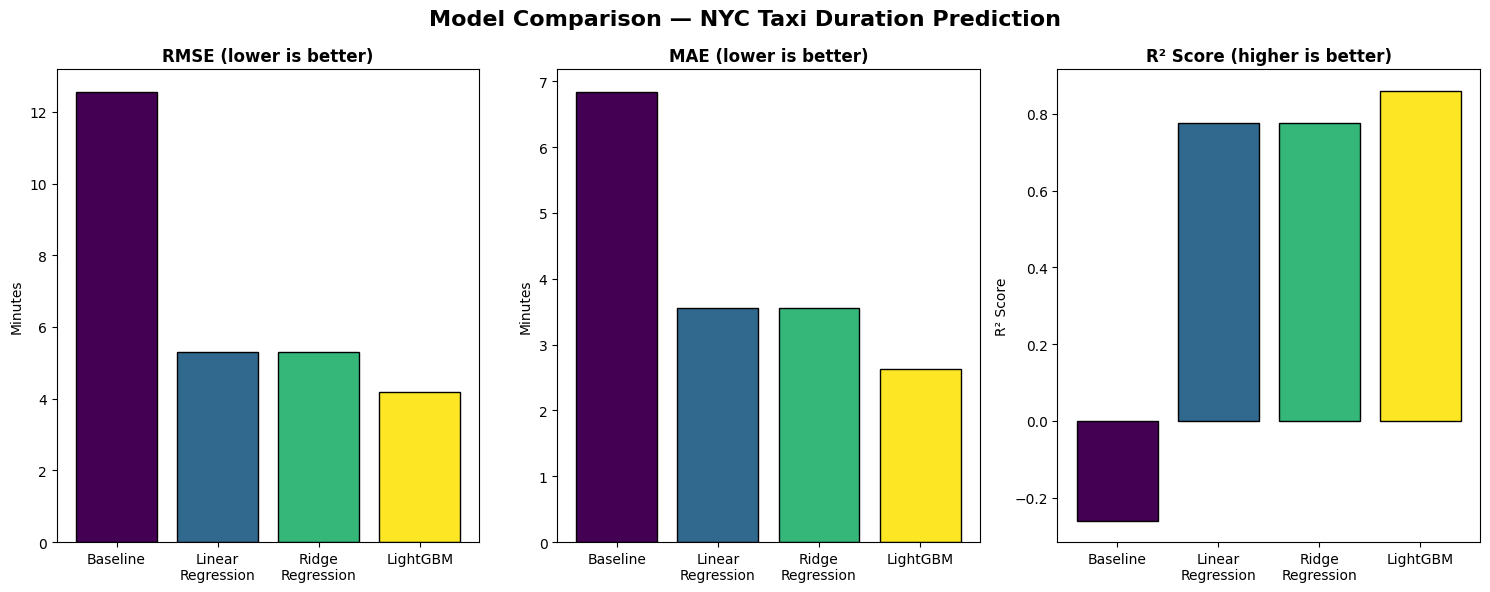

In [ ]:
models = ["Baseline", "Linear\nRegression", "Ridge\nRegression", "LightGBM"]
rmse_scores = [12.56, 5.29, 5.29, 4.18]
mae_scores  = [6.84,  3.56, 3.56, 2.63]
r2_scores   = [-0.26, 0.7765, 0.7765, 0.8603]

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

colors = ["#440154", "#31688E", "#35B779", "#FDE725"]

axes[0].bar(models, rmse_scores, color=colors, edgecolor="black")
axes[0].set_title("RMSE (lower is better)", fontweight="bold")
axes[0].set_ylabel("Minutes")

axes[1].bar(models, mae_scores, color=colors, edgecolor="black")
axes[1].set_title("MAE (lower is better)", fontweight="bold")
axes[1].set_ylabel("Minutes")

axes[2].bar(models, r2_scores, color=colors, edgecolor="black")
axes[2].set_title("R² Score (higher is better)", fontweight="bold")
axes[2].set_ylabel("R² Score")

plt.suptitle("Model Comparison — NYC Taxi Duration Prediction", 
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("chart9_model_comparison.png", dpi=150)
plt.show()

### Feature Importance — What drives trip duration?
This shows which features my LightGBM model relies on most.

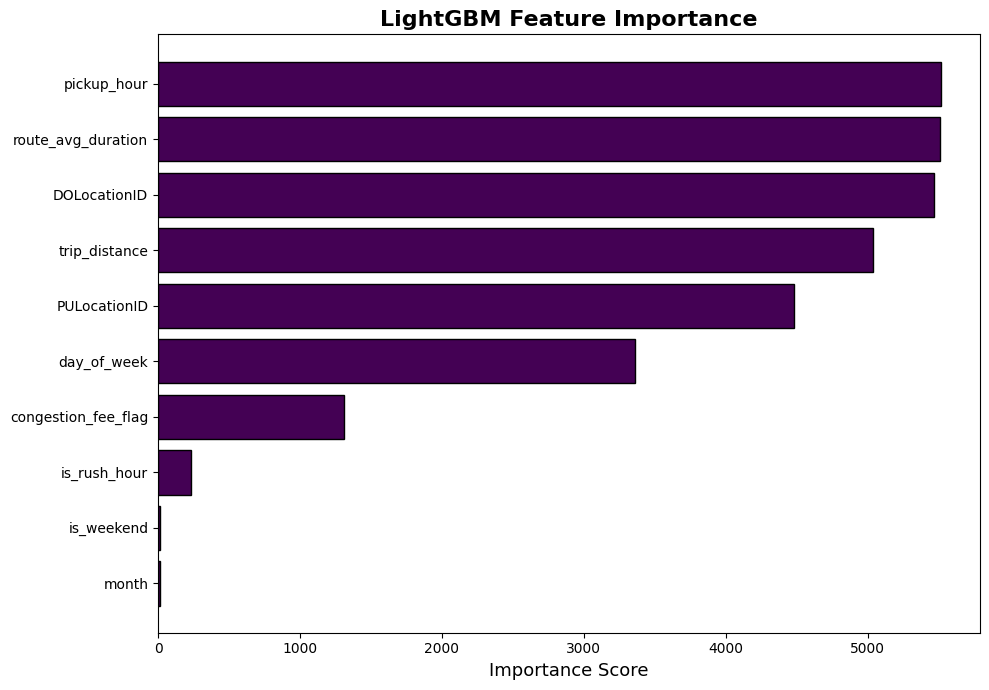

In [ ]:
importance = pd.DataFrame({
    "feature": features,
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(importance["feature"], importance["importance"],
         color="#440154", edgecolor="black")

plt.title("LightGBM Feature Importance", fontsize=16, fontweight="bold")
plt.xlabel("Importance Score", fontsize=13)
plt.tight_layout()
plt.savefig("chart10_feature_importance.png", dpi=150)
plt.show()

### Actual vs Predicted Trip Duration
This shows how well my LightGBM model predictions match reality.
Then code cell:

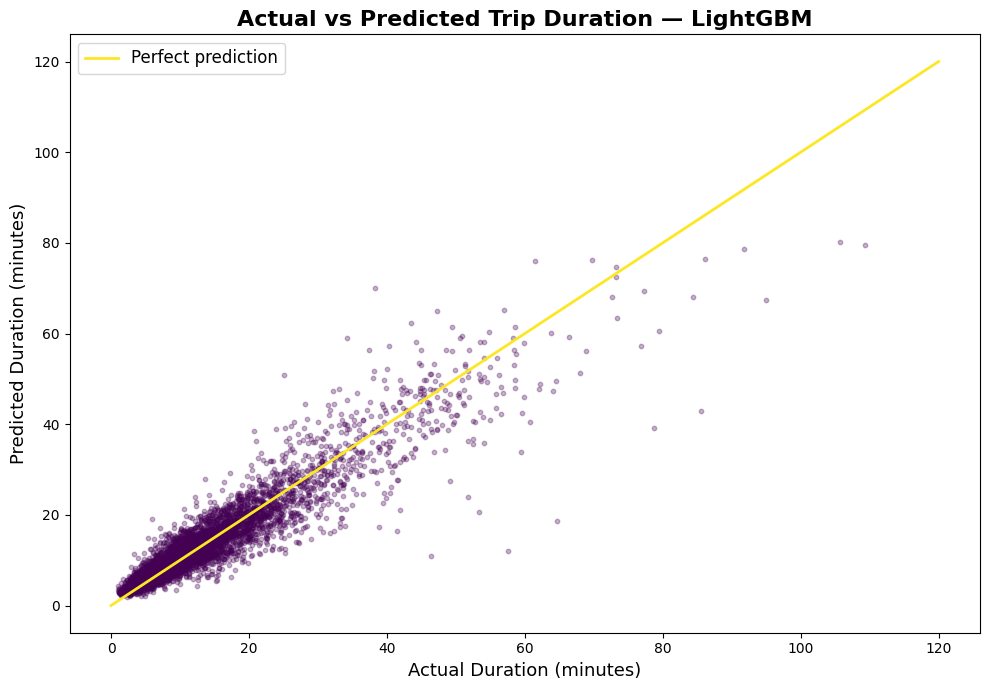

In [ ]:
sample = 5000
idx = np.random.choice(len(y_test), sample, replace=False)

plt.figure(figsize=(10, 7))
plt.scatter(y_test.iloc[idx], lgb_preds[idx], 
            alpha=0.3, color="#440154", s=10)
plt.plot([0, 120], [0, 120], 
         color="#FDE725", linewidth=2, label="Perfect prediction")

plt.title("Actual vs Predicted Trip Duration — LightGBM", 
          fontsize=16, fontweight="bold")
plt.xlabel("Actual Duration (minutes)", fontsize=13)
plt.ylabel("Predicted Duration (minutes)", fontsize=13)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("chart11_actual_vs_predicted.png", dpi=150)
plt.show()

In [ ]:
import joblib
import os

os.makedirs("models", exist_ok=True)
joblib.dump(lgb_model, "models/lightgbm_model.pkl")
print("Model saved to models/lightgbm_model.pkl Successfully!")

Model saved to models/lightgbm_model.pkl Successfully!


### Model 5: Random Forest With Hyperparameter Tuning
A powerful tree-based ensemble model. We tune key hyperparameters to optimize performance.

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Hyperparameter tuning for Random Forest
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    rf, param_grid, 
    cv=3, 
    scoring="neg_mean_squared_error",
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"✅ Best parameters: {grid_search.best_params_}")

rf_best = grid_search.best_estimator_
rf_preds = rf_best.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_mae  = mean_absolute_error(y_test, rf_preds)
rf_r2   = r2_score(y_test, rf_preds)

print(f"\n=== Model 5: Random Forest ===")
print(f"RMSE : {rf_rmse:.2f} minutes")
print(f"MAE  : {rf_mae:.2f} minutes")
print(f"R²   : {rf_r2:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
✅ Best parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}

=== Model 5: Random Forest ===
RMSE : 4.22 minutes
MAE  : 2.65 minutes
R²   : 0.8578


In [7]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (1600000, 10)
X_test shape: (400000, 10)


In [8]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import lightgbm as lgb
import joblib
import gc

# Load data
df = pd.read_csv("../data/processed/yellow_taxi_2025_clean.csv", nrows=2000000)

# Recreate features
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["pickup_hour"]  = df["tpep_pickup_datetime"].dt.hour
df["day_of_week"]  = df["tpep_pickup_datetime"].dt.dayofweek
df["month"]        = df["tpep_pickup_datetime"].dt.month
df["is_weekend"]   = (df["day_of_week"] >= 5).astype(int)
df["is_rush_hour"] = (df["pickup_hour"].between(7,9) | df["pickup_hour"].between(17,19)).astype(int)

route_avg = df.groupby(["PULocationID","DOLocationID"])["duration_minutes"].mean().reset_index()
route_avg.columns = ["PULocationID","DOLocationID","route_avg_duration"]
df = df.merge(route_avg, on=["PULocationID","DOLocationID"], how="left")
df["congestion_fee_flag"] = (df["cbd_congestion_fee"] > 0).astype(int)

# Features and target
features = ["trip_distance","pickup_hour","day_of_week","month",
            "is_weekend","is_rush_hour","route_avg_duration",
            "congestion_fee_flag","PULocationID","DOLocationID"]
target = "duration_minutes"

df_model = df[features + [target]].dropna()
split = int(len(df_model) * 0.8)
train = df_model.iloc[:split]
test  = df_model.iloc[split:]

X_train = train[features]
y_train = train[target]
X_test  = test[features]
y_test  = test[target]

print(f"Successful X_train: {X_train.shape}")
print(f"Successful X_test: {X_test.shape}")
print("Successfully Ready for Random Forest!")

Successful X_train: (1600000, 10)
Successful X_test: (400000, 10)
Successfully Ready for Random Forest!


In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Smaller grid = much faster!
param_grid = {
    "n_estimators": [100],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(rf, param_grid, cv=2, 
                           scoring="neg_mean_squared_error", verbose=1)
grid_search.fit(X_train, y_train)

print(f"✅ Best parameters: {grid_search.best_params_}")
rf_best = grid_search.best_estimator_
rf_preds = rf_best.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_mae  = mean_absolute_error(y_test, rf_preds)
rf_r2   = r2_score(y_test, rf_preds)

print(f"\n=== Model 4: Random Forest ===")
print(f"RMSE : {rf_rmse:.2f} minutes")
print(f"MAE  : {rf_mae:.2f} minutes")
print(f"R²   : {rf_r2:.4f}")

Fitting 2 folds for each of 4 candidates, totalling 8 fits
✅ Best parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}

=== Model 4: Random Forest ===
RMSE : 4.22 minutes
MAE  : 2.65 minutes
R²   : 0.8576


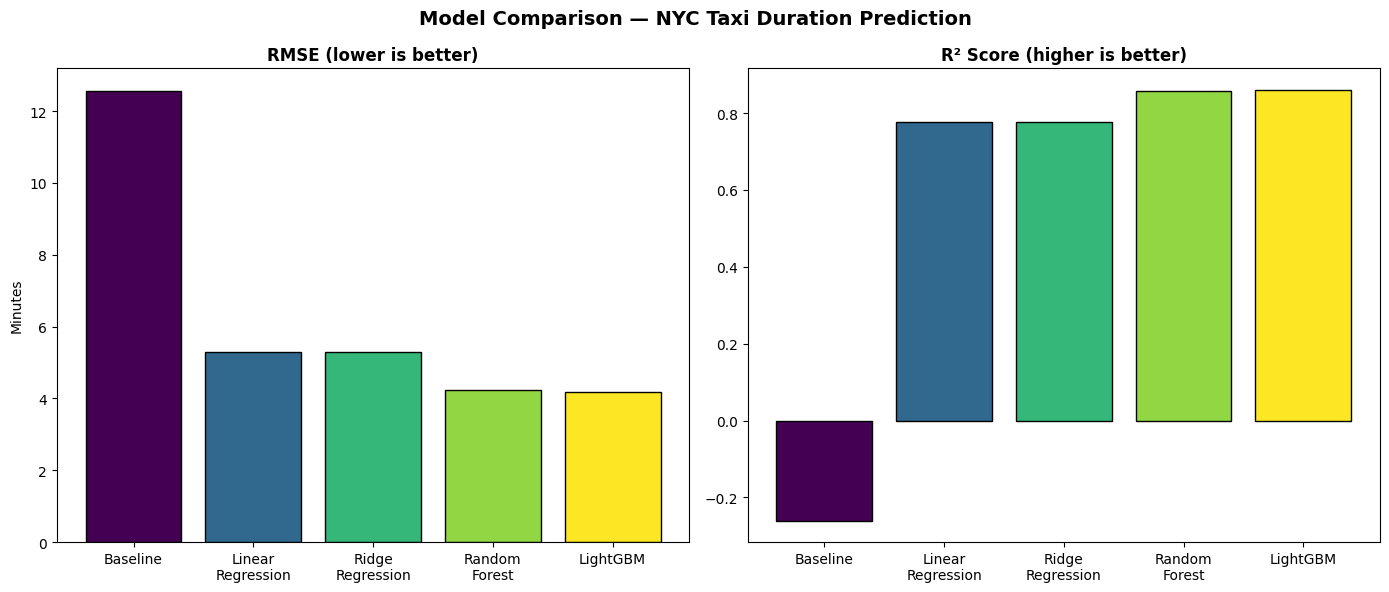

Successfully updated chart saved!


In [11]:
import matplotlib.pyplot as plt

models = ["Baseline", "Linear\nRegression", "Ridge\nRegression", 
          "Random\nForest", "LightGBM"]
rmse_scores = [12.56, 5.29, 5.29, 4.22, 4.18]
r2_scores   = [-0.26, 0.7765, 0.7765, 0.8576, 0.8603]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ["#440154","#31688E","#35B779","#90D743","#FDE725"]

axes[0].bar(models, rmse_scores, color=colors, edgecolor="black")
axes[0].set_title("RMSE (lower is better)", fontweight="bold")
axes[0].set_ylabel("Minutes")

axes[1].bar(models, r2_scores, color=colors, edgecolor="black")
axes[1].set_title("R² Score (higher is better)", fontweight="bold")

plt.suptitle("Model Comparison — NYC Taxi Duration Prediction",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("chart9_model_comparison.png", dpi=150)
plt.show()
print("Successfully updated chart saved!")